# Dengue Disease Analysis - India
### ARTPARK Internship Assignment

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## Loading the Data

In [2]:
# loading the main dengue dataset (national level from OpenDengue)
dengue = pd.read_csv("DENGUE_filtered_data.csv")
print(dengue.shape)
dengue.head()

(35, 17)


,adm_0_name,adm_1_name,adm_2_name,full_name,ISO_A0,FAO_GAUL_code,RNE_iso_code,IBGE_code,calendar_start_date,calendar_end_date,Year,dengue_total,case_definition_standardised,S_res,T_res,UUID,region
0,INDIA,NaN,NaN,INDIA,IND,115,IND,NaN,1995-01-01,1995-12-31,1995,7847,Total,Admin0,Year,WHOSEARO-ALL-19852009-Y01-00,SEARO
1,INDIA,NaN,NaN,INDIA,IND,115,IND,NaN,1991-01-01,1991-12-31,1991,6291,Total,Admin0,Year,WHOSEARO-ALL-19852009-Y01-00,SEARO
2,INDIA,NaN,NaN,INDIA,IND,115,IND,NaN,1992-01-01,1992-12-31,1992,2683,Total,Admin0,Year,WHOSEARO-ALL-19852009-Y01-00,SEARO
3,INDIA,NaN,NaN,INDIA,IND,115,IND,NaN,1993-01-01,1993-12-31,1993,11125,Total,Admin0,Year,WHOSEARO-ALL-19852009-Y01-00,SEARO
4,INDIA,NaN,NaN,INDIA,IND,115,IND,NaN,1994-01-01,1994-12-31,1994,7494,Total,Admin0,Year,WHOSEARO-ALL-19852009-Y01-00,SEARO


In [3]:
# loading NCVBDC state level data
ncvbdc = pd.read_csv("dengue_ncvbdc_2021_2025.csv")
print(ncvbdc.shape)
ncvbdc.head()

(40, 13)


,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11
0,0,Sl. No.,Affected States/UTs,2021,2021,2022,2022,2023,2023,2024,2024,2025*,2025*
1,1,Sl. No.,Affected States/UTs,C,D,C,D,C,D,C,D,C,D
2,2,1,Andhra Pradesh,4760,0,6391,0,6453,0,5555,2,2386,5
3,3,2,Arunachal Pradesh,7,0,114,0,130,0,20,0,412,0
4,4,3,Assam,103,0,1826,2,8208,7,2271,0,618,0


In [4]:
# google mobility data
mobility = pd.read_csv("Global_Mobility_Report.csv", low_memory=False)
# only keeping India rows
mobility = mobility[mobility['country_region'] == 'India']
print(mobility.shape)
mobility.head()

(649545, 15)


,country_region_code,country_region,sub_region_1,sub_region_2,metro_area,iso_3166_2_code,census_fips_code,place_id,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
5028430,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-15,1.0,2.0,3.0,3.0,5.0,0.0
5028431,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-16,2.0,2.0,3.0,2.0,0.0,0.0
5028432,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-17,-1.0,1.0,3.0,1.0,4.0,0.0
5028433,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-18,0.0,2.0,4.0,2.0,3.0,0.0
5028434,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-19,0.0,2.0,1.0,1.0,4.0,1.0


## EDA - Exploratory Data Analysis

In [5]:
# checking the national dengue data
print(dengue.columns.tolist())
print()
print(dengue.dtypes)
print()
print(dengue.isnull().sum())

['adm_0_name', 'adm_1_name', 'adm_2_name', 'full_name', 'ISO_A0', 'FAO_GAUL_code', 'RNE_iso_code', 'IBGE_code', 'calendar_start_date', 'calendar_end_date', 'Year', 'dengue_total', 'case_definition_standardised', 'S_res', 'T_res', 'UUID', 'region']

adm_0_name                       object
adm_1_name                      float64
adm_2_name                      float64
full_name                        object
ISO_A0                           object
FAO_GAUL_code                     int64
RNE_iso_code                     object
IBGE_code                       float64
calendar_start_date              object
calendar_end_date                object
Year                              int64
dengue_total                      int64
case_definition_standardised     object
S_res                            object
T_res                            object
UUID                             object
region                           object
dtype: object

adm_0_name                       0
adm_1_name           

In [6]:
# only want yearly data at national level
national = dengue[dengue['T_res'] == 'Year'][['Year', 'dengue_total']].copy()
national = national.sort_values('Year').drop_duplicates('Year').reset_index(drop=True)
print(national)

    Year  dengue_total
0   1991          6291
1   1992          2683
2   1993         11125
3   1994          7494
4   1995          7847
5   1996         16517
6   1997          1177
7   1998           707
8   1999           944
9   2000           650
10  2001          3306
11  2002          1926
12  2003         12754
13  2004          4153
14  2005         11985
15  2006         12317
16  2007          5530
17  2008         12540
18  2009         15535
19  2010         28292
20  2011         18860
21  2012         37070
22  2013         55153
23  2014         28933
24  2015         99913
25  2016        129166
26  2017        188401
27  2018        101192
28  2019        157315
29  2020         44585
30  2021        193245
31  2022        233251
32  2023        289235
33  2024        233519


In [7]:
# basic stats
print(national['dengue_total'].describe())

count        34.000000
mean      58047.382353
std       82094.626850
min         650.000000
25%        5720.250000
50%       14144.500000
75%       88723.000000
max      289235.000000
Name: dengue_total, dtype: float64


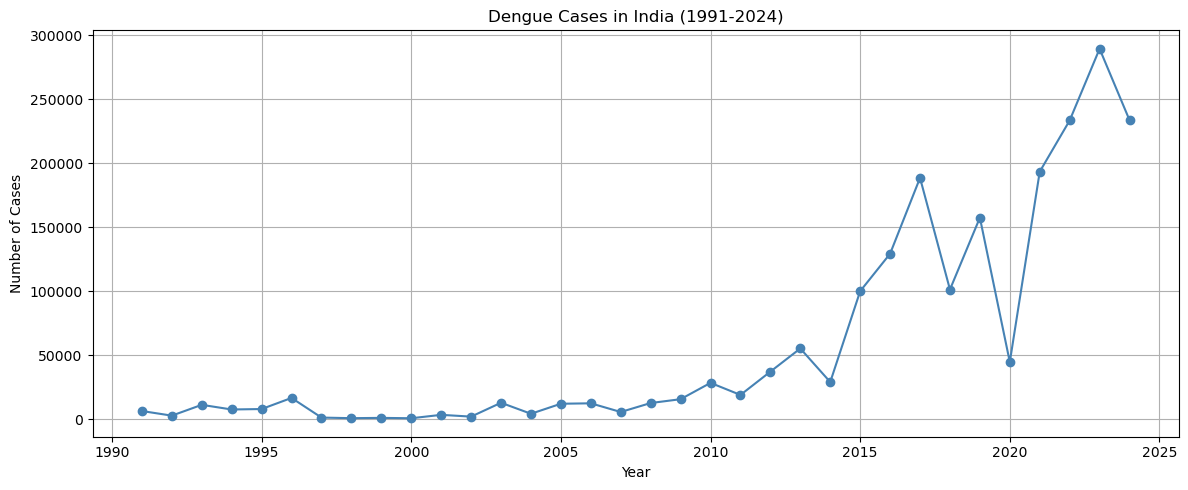

In [8]:
# plotting dengue cases over the years
plt.figure(figsize=(12, 5))
plt.plot(national['Year'], national['dengue_total'], marker='o', color='steelblue')
plt.title('Dengue Cases in India (1991-2024)')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.tight_layout()
plt.show()

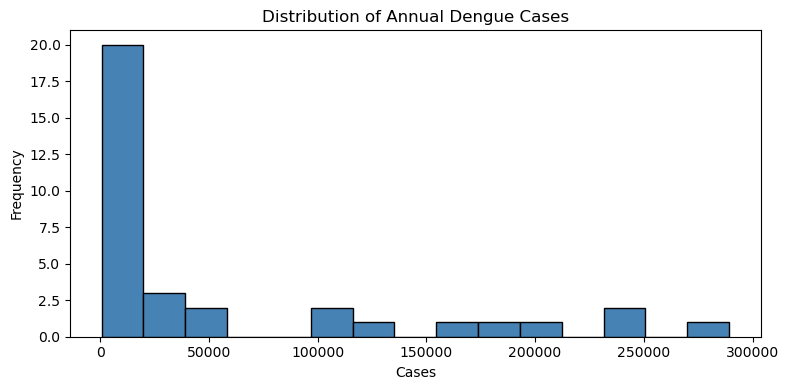

In [9]:
# cases went really low in 2020 - probably because of covid lockdowns reducing outdoor exposure
# and also maybe underreporting during covid

# let's see the distribution
plt.figure(figsize=(8, 4))
plt.hist(national['dengue_total'], bins=15, color='steelblue', edgecolor='black')
plt.title('Distribution of Annual Dengue Cases')
plt.xlabel('Cases')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### State Level Data (NCVBDC 2021-2024)

In [10]:
# the ncvbdc data is a bit messy - need to clean it up
print(ncvbdc.to_string())

    Unnamed: 0        0                    1       2     3       4     5       6     7       8     9           10           11
0            0  Sl. No.  Affected States/UTs    2021  2021    2022  2022    2023  2023    2024  2024        2025*        2025*
1            1  Sl. No.  Affected States/UTs       C     D       C     D       C     D       C     D            C            D
2            2        1       Andhra Pradesh    4760     0    6391     0    6453     0    5555     2         2386            5
3            3        2    Arunachal Pradesh       7     0     114     0     130     0      20     0          412            0
4            4        3                Assam     103     0    1826     2    8208     7    2271     0          618            0
5            5        4                Bihar     633     2   13972    32   20224    74   10157    16         3774            2
6            6        5          Chattisgarh    1086     0    2679    10    2412     0    3523     2          4

In [11]:
# fixing the column names and reshaping
ncvbdc_clean = ncvbdc.iloc[2:-1].copy()
ncvbdc_clean.columns = ['_', 'sl', 'state',
    '2021_C', '2021_D', '2022_C', '2022_D',
    '2023_C', '2023_D', '2024_C', '2024_D',
    '2025_C', '2025_D']
ncvbdc_clean = ncvbdc_clean[['state', '2021_C', '2022_C', '2023_C', '2024_C',
                               '2021_D', '2022_D', '2023_D', '2024_D']].copy()
ncvbdc_clean['state'] = ncvbdc_clean['state'].str.strip()

# convert to numeric
for col in ncvbdc_clean.columns[1:]:
    ncvbdc_clean[col] = pd.to_numeric(ncvbdc_clean[col], errors='coerce')

ncvbdc_clean = ncvbdc_clean.dropna(subset=['2021_C'])
ncvbdc_clean.head(10)

,state,2021_C,2022_C,2023_C,2024_C,2021_D,2022_D,2023_D,2024_D
2,Andhra Pradesh,4760.0,6391.0,6453.0,5555.0,0.0,0.0,0.0,2.0
3,Arunachal Pradesh,7.0,114.0,130.0,20.0,0.0,0.0,0.0,0.0
4,Assam,103.0,1826.0,8208.0,2271.0,0.0,2.0,7.0,0.0
5,Bihar,633.0,13972.0,20224.0,10157.0,2.0,32.0,74.0,16.0
6,Chattisgarh,1086.0,2679.0,2412.0,3523.0,0.0,10.0,0.0,2.0
7,Goa,649.0,443.0,512.0,567.0,0.0,1.0,3.0,3.0
8,Gujarat,10983.0,6682.0,7222.0,7891.0,14.0,7.0,7.0,6.0
9,Haryana,11835.0,8996.0,8081.0,6469.0,13.0,18.0,11.0,9.0
10,Himachal Pradesh,349.0,3326.0,1989.0,3359.0,0.0,1.0,0.0,0.0
11,J & K,1709.0,8269.0,6403.0,6876.0,4.0,18.0,10.0,1.0


In [12]:
# top 10 states by dengue cases in 2024
top10 = ncvbdc_clean.nlargest(10, '2024_C')[['state', '2024_C']].reset_index(drop=True)
print(top10)

            state   2024_C
0       Karnataka  32886.0
1      Tamil Nadu  27378.0
2          Kerala  20674.0
3     Maharashtra  19385.0
4   Uttar Pradesh  15868.0
5       Rajasthan  12514.0
6           Delhi  10585.0
7  Madhya Pradesh  10224.0
8           Bihar  10157.0
9       Telangana  10077.0


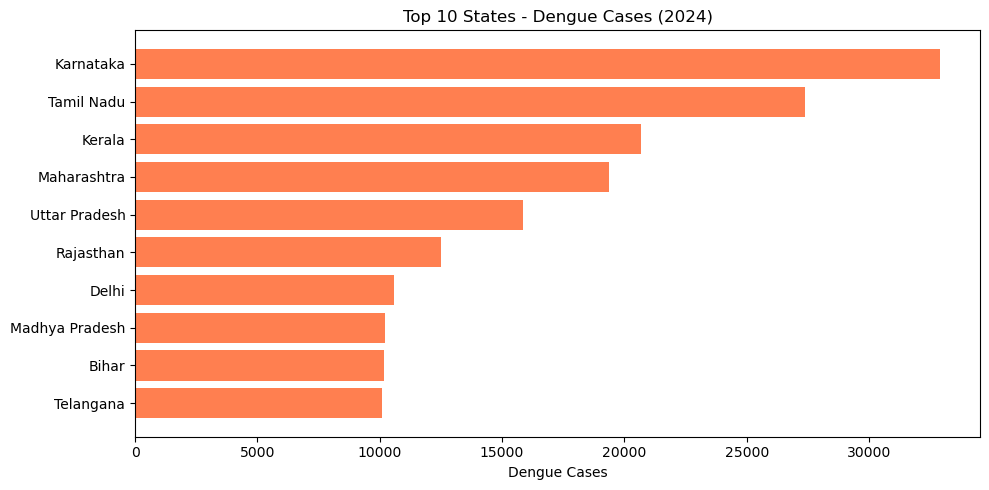

In [13]:
plt.figure(figsize=(10, 5))
plt.barh(top10['state'], top10['2024_C'], color='coral')
plt.xlabel('Dengue Cases')
plt.title('Top 10 States - Dengue Cases (2024)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

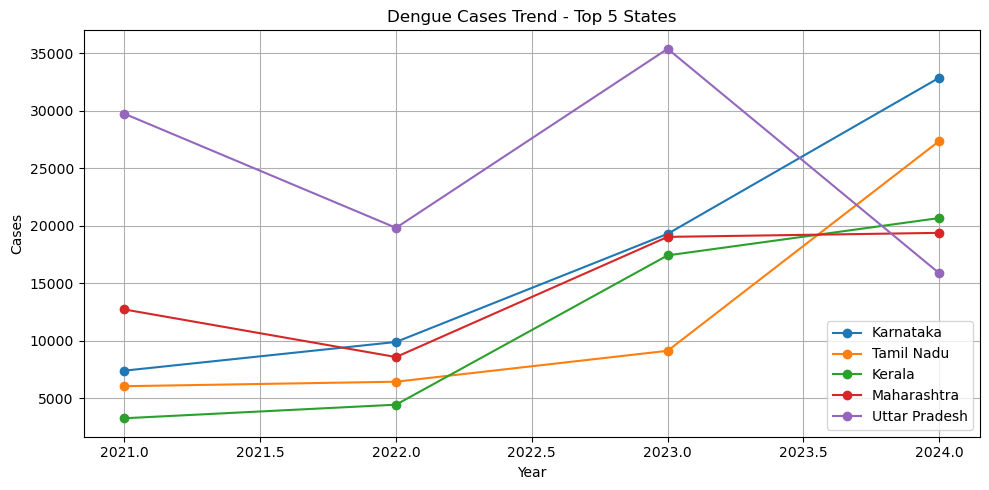

In [14]:
# how cases changed year on year for top 5 states
top5_states = ncvbdc_clean.nlargest(5, '2024_C')['state'].tolist()

plt.figure(figsize=(10, 5))
for state in top5_states:
    row = ncvbdc_clean[ncvbdc_clean['state'] == state].iloc[0]
    cases = [row['2021_C'], row['2022_C'], row['2023_C'], row['2024_C']]
    plt.plot([2021, 2022, 2023, 2024], cases, marker='o', label=state)

plt.title('Dengue Cases Trend - Top 5 States')
plt.xlabel('Year')
plt.ylabel('Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# total cases per year (national level from NCVBDC)
yearly_totals = {
    2021: ncvbdc_clean['2021_C'].sum(),
    2022: ncvbdc_clean['2022_C'].sum(),
    2023: ncvbdc_clean['2023_C'].sum(),
    2024: ncvbdc_clean['2024_C'].sum()
}
print("Total cases per year (NCVBDC):")
for yr, total in yearly_totals.items():
    print(f"  {yr}: {int(total):,}")

Total cases per year (NCVBDC):
  2021: 193,245
  2022: 233,251
  2023: 289,235
  2024: 233,519


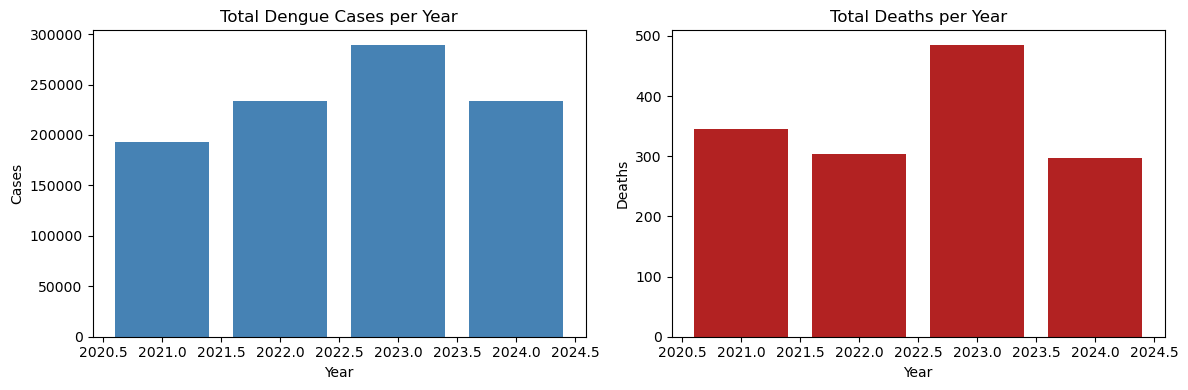

In [16]:
# deaths data
yearly_deaths = {
    2021: ncvbdc_clean['2021_D'].sum(),
    2022: ncvbdc_clean['2022_D'].sum(),
    2023: ncvbdc_clean['2023_D'].sum(),
    2024: ncvbdc_clean['2024_D'].sum()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(yearly_totals.keys(), yearly_totals.values(), color='steelblue')
axes[0].set_title('Total Dengue Cases per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Cases')

axes[1].bar(yearly_deaths.keys(), yearly_deaths.values(), color='firebrick')
axes[1].set_title('Total Deaths per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Deaths')

plt.tight_layout()
plt.show()

### Google Mobility Data Analysis

In [17]:
print(mobility.columns.tolist())
print(mobility.shape)
mobility.head()

['country_region_code', 'country_region', 'sub_region_1', 'sub_region_2', 'metro_area', 'iso_3166_2_code', 'census_fips_code', 'place_id', 'date', 'retail_and_recreation_percent_change_from_baseline', 'grocery_and_pharmacy_percent_change_from_baseline', 'parks_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline', 'workplaces_percent_change_from_baseline', 'residential_percent_change_from_baseline']
(649545, 15)


,country_region_code,country_region,sub_region_1,sub_region_2,metro_area,iso_3166_2_code,census_fips_code,place_id,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
5028430,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-15,1.0,2.0,3.0,3.0,5.0,0.0
5028431,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-16,2.0,2.0,3.0,2.0,0.0,0.0
5028432,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-17,-1.0,1.0,3.0,1.0,4.0,0.0
5028433,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-18,0.0,2.0,4.0,2.0,3.0,0.0
5028434,IN,India,NaN,NaN,NaN,NaN,NaN,ChIJkbeSa_BfYzARphNChaFPjNc,2020-02-19,0.0,2.0,1.0,1.0,4.0,1.0


In [18]:
# keeping only state level rows (sub_region_1 is state, sub_region_2 is district)
mob_state = mobility[mobility['sub_region_1'].notna() & mobility['sub_region_2'].isna()].copy()
mob_state['date'] = pd.to_datetime(mob_state['date'])
mob_state['year'] = mob_state['date'].dt.year
print(mob_state['year'].value_counts().sort_index())

year
2020    11528
2021    13140
2022    10368
Name: count, dtype: int64


In [19]:
# average mobility by year (India level)
mob_cols = ['retail_and_recreation_percent_change_from_baseline',
            'grocery_and_pharmacy_percent_change_from_baseline',
            'parks_percent_change_from_baseline',
            'transit_stations_percent_change_from_baseline',
            'workplaces_percent_change_from_baseline',
            'residential_percent_change_from_baseline']

mob_yearly = mob_state.groupby('year')[mob_cols].mean()
print(mob_yearly.round(2))

      retail_and_recreation_percent_change_from_baseline  \
year                                                       
2020                                             -40.41    
2021                                             -10.16    
2022                                              31.23    

      grocery_and_pharmacy_percent_change_from_baseline  \
year                                                      
2020                                              -4.65   
2021                                              29.44   
2022                                              69.30   

      parks_percent_change_from_baseline  \
year                                       
2020                              -27.14   
2021                                3.29   
2022                               84.27   

      transit_stations_percent_change_from_baseline  \
year                                                  
2020                                         -20.66   
2021             

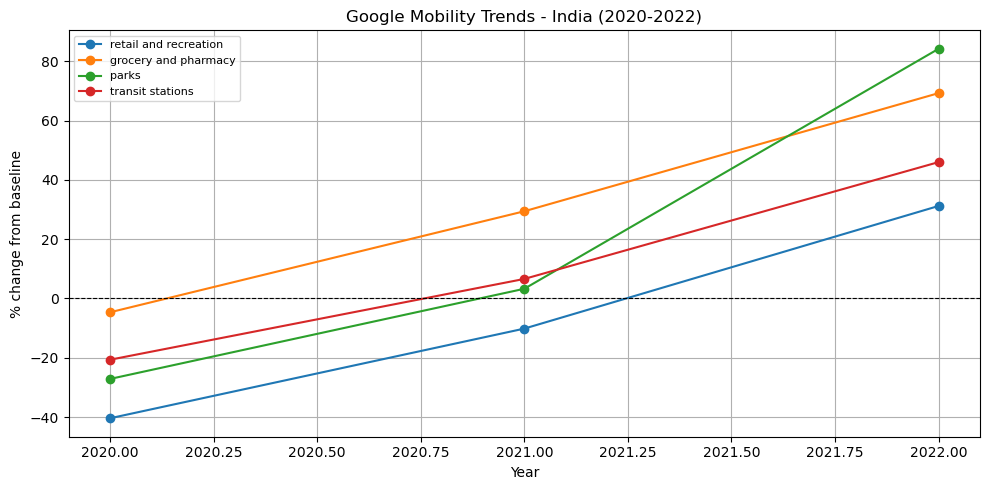

In [20]:
# plotting mobility trends
plt.figure(figsize=(10, 5))
for col in mob_cols[:4]:
    label = col.replace('_percent_change_from_baseline', '').replace('_', ' ')
    plt.plot(mob_yearly.index, mob_yearly[col], marker='o', label=label)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Google Mobility Trends - India (2020-2022)')
plt.xlabel('Year')
plt.ylabel('% change from baseline')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### Correlation Analysis

In [21]:
# making a combined dataset to check correlations
# using only 2021-2022 where both mobility and dengue data overlap

mob_2021_2022 = mob_state[mob_state['year'].isin([2021, 2022])].copy()
mob_agg = mob_2021_2022.groupby(['sub_region_1', 'year'])[mob_cols].mean().reset_index()
mob_agg.columns = ['state', 'year'] + ['mob_retail', 'mob_grocery', 'mob_parks',
                                        'mob_transit', 'mob_workplace', 'mob_residential']
print(mob_agg.shape)
mob_agg.head()

(72, 8)


,state,year,mob_retail,mob_grocery,mob_parks,mob_transit,mob_workplace,mob_residential
0,Andaman and Nicobar Islands,2021,23.487671,NaN,-5.109589,48.063014,17.213699,11.915068
1,Andaman and Nicobar Islands,2022,103.093750,NaN,82.121528,75.274306,66.802083,20.527778
2,Andhra Pradesh,2021,-15.758904,34.082192,-9.493151,-7.063014,-10.131507,8.797260
3,Andhra Pradesh,2022,8.968750,54.777778,47.635417,22.375000,20.326389,13.878472
4,Arunachal Pradesh,2021,-27.898630,12.545205,19.413699,-26.005479,-21.583562,9.339726


In [22]:
# tidy format for state dengue
rows = []
for yr in [2021, 2022, 2023, 2024]:
    tmp = ncvbdc_clean[['state', f'{yr}_C', f'{yr}_D']].copy()
    tmp.columns = ['state', 'cases', 'deaths']
    tmp['year'] = yr
    rows.append(tmp)
state_df = pd.concat(rows, ignore_index=True)
state_df['cases'] = pd.to_numeric(state_df['cases'], errors='coerce')
state_df['deaths'] = pd.to_numeric(state_df['deaths'], errors='coerce')
state_df = state_df.dropna(subset=['cases'])
print(state_df.shape)

(144, 4)


In [23]:
# name mapping because google mobility uses different state names
name_map = {
    'Chattisgarh': 'Chhattisgarh',
    'J & K': 'Jammu and Kashmir',
    'A& N Island': 'Andaman and Nicobar Islands',
    'Puduchery': 'Puducherry',
    'Uttrakhand': 'Uttarakhand',
    'West Bengal*': 'West Bengal',
    'D&N Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',
}
state_df['state_mob'] = state_df['state'].map(lambda x: name_map.get(x, x))

merged = state_df.merge(mob_agg, left_on=['state_mob', 'year'],
                        right_on=['state', 'year'], how='left')
merged = merged.drop(columns=['state_y']).rename(columns={'state_x': 'state'})
print(merged.shape)

(144, 11)


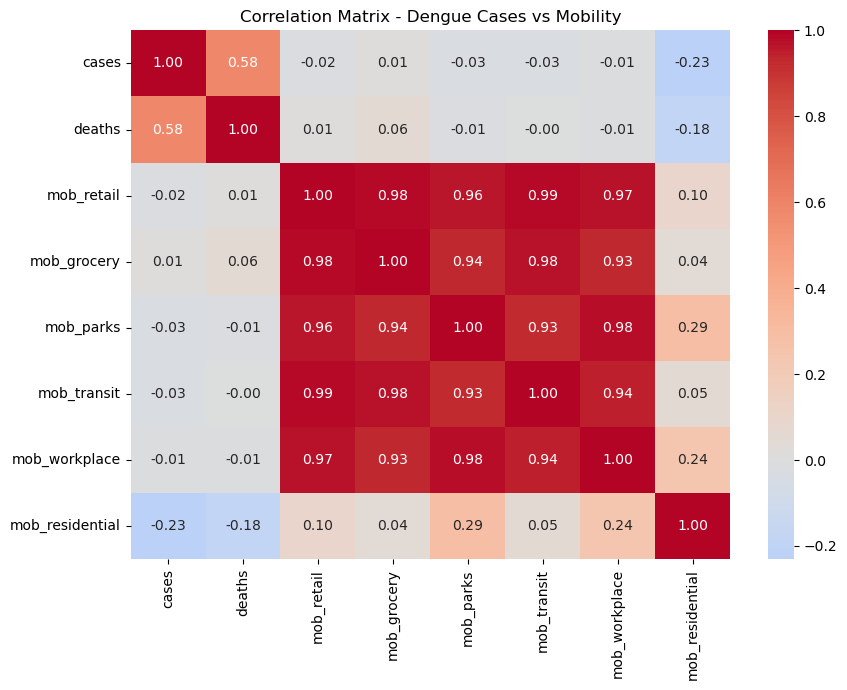

In [24]:
# correlation heatmap
corr_cols = ['cases', 'deaths', 'mob_retail', 'mob_grocery',
             'mob_parks', 'mob_transit', 'mob_workplace', 'mob_residential']
corr_data = merged[corr_cols].dropna()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Dengue Cases vs Mobility')
plt.tight_layout()
plt.show()

## Modelling

I'll build two models:
1. Linear Regression on national annual data to see the trend
2. Random Forest on state-level panel data to predict cases

### Model 1 - Linear Regression (National Trend)

In [25]:
# using year as the feature to predict national cases
# simple but shows the trend

X = national[['Year']]
y = national['dengue_total']

# train on 1991-2018, test on 2019-2024
X_train = X[X['Year'] <= 2018]
y_train = y[X['Year'] <= 2018]
X_test  = X[X['Year'] > 2018]
y_test  = y[X['Year'] > 2018]

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression Results (test: 2019-2024):")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R2 (train): {lr.score(X_train, y_train):.3f}")

Linear Regression Results (test: 2019-2024):
MAE  : 111,374
RMSE : 120,608
R2 (train): 0.493


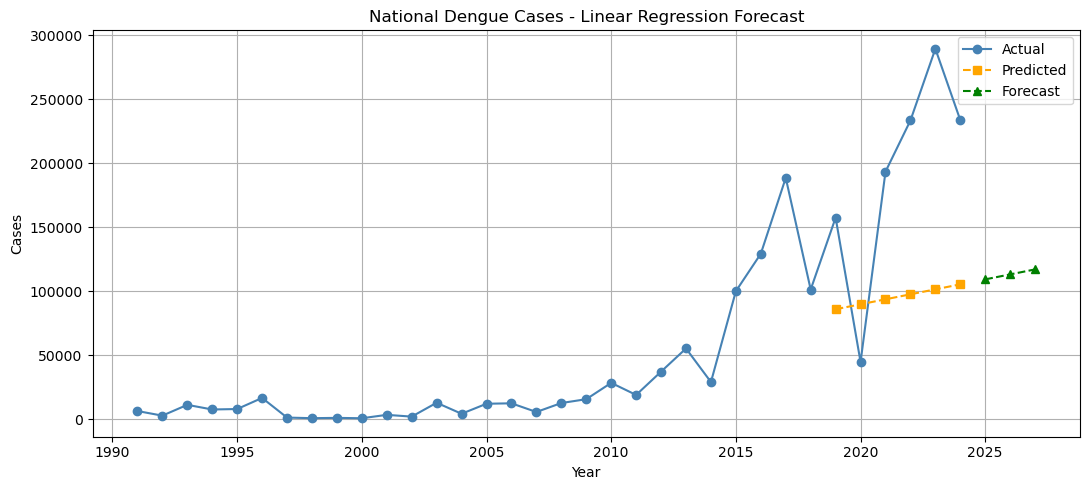

Forecast:
  2025: 109,134
  2026: 113,024
  2027: 116,915


In [26]:
plt.figure(figsize=(11, 5))
plt.plot(national['Year'], national['dengue_total'], 'o-', label='Actual', color='steelblue')
plt.plot(X_test['Year'], y_pred, 's--', label='Predicted', color='orange')

# extend to 2027
future_years = pd.DataFrame({'Year': [2025, 2026, 2027]})
future_pred = lr.predict(future_years)
plt.plot(future_years['Year'], future_pred, '^--', label='Forecast', color='green')

plt.title('National Dengue Cases - Linear Regression Forecast')
plt.xlabel('Year')
plt.ylabel('Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Forecast:")
for yr, pred in zip([2025, 2026, 2027], future_pred):
    print(f"  {yr}: {int(pred):,}")

### Model 2 - Random Forest (State Level Panel)

In [27]:
# adding population data (approximate state populations in millions)
pop = {
    'Andhra Pradesh': 53.9, 'Arunachal Pradesh': 1.7, 'Assam': 35.6,
    'Bihar': 128.5, 'Chattisgarh': 31.2, 'Goa': 1.6,
    'Gujarat': 68.3, 'Haryana': 29.8, 'Himachal Pradesh': 7.5,
    'J & K': 14.3, 'Jharkhand': 40.1, 'Karnataka': 69.6,
    'Kerala': 36.0, 'Lakshadweep': 0.07, 'Madhya Pradesh': 87.5,
    'Meghalaya': 3.8, 'Maharashtra': 128.2, 'Manipur': 3.4,
    'Mizoram': 1.4, 'Nagaland': 2.2, 'Odisha': 46.9,
    'Punjab': 31.4, 'Rajasthan': 82.7, 'Sikkim': 0.76,
    'Tamil Nadu': 81.6, 'Tripura': 4.2, 'Telangana': 39.4,
    'Uttrakhand': 11.7, 'Uttar Pradesh': 241.1, 'West Bengal*': 101.4,
    'A& N Island': 0.42, 'Chandigarh': 1.16, 'D&N Haveli': 0.62,
    'Daman & Diu': 0.33, 'Delhi': 20.7, 'Puduchery': 1.79
}
state_df['population'] = state_df['state'].map(pop)
state_df['cases_per_lakh'] = state_df['cases'] / (state_df['population'] * 10)

# lag feature - previous year cases per state
state_df = state_df.sort_values(['state', 'year'])
state_df['prev_year_cases'] = state_df.groupby('state')['cases'].shift(1)

# fill 2021 lag with own value (no 2020 state data available)
state_df['prev_year_cases'] = state_df['prev_year_cases'].fillna(state_df['cases'])

state_df.head(8)

,state,cases,deaths,year,state_mob,population,cases_per_lakh,prev_year_cases
30,A& N Island,175.0,0.0,2021,Andaman and Nicobar Islands,0.42,41.666667,175.0
66,A& N Island,1014.0,3.0,2022,Andaman and Nicobar Islands,0.42,241.428571,175.0
102,A& N Island,846.0,0.0,2023,Andaman and Nicobar Islands,0.42,201.428571,1014.0
138,A& N Island,59.0,0.0,2024,Andaman and Nicobar Islands,0.42,14.047619,846.0
0,Andhra Pradesh,4760.0,0.0,2021,Andhra Pradesh,53.90,8.831169,4760.0
36,Andhra Pradesh,6391.0,0.0,2022,Andhra Pradesh,53.90,11.857143,4760.0
72,Andhra Pradesh,6453.0,0.0,2023,Andhra Pradesh,53.90,11.972171,6391.0
108,Andhra Pradesh,5555.0,2.0,2024,Andhra Pradesh,53.90,10.306122,6453.0


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
state_df['state_code'] = le.fit_transform(state_df['state'])

features = ['state_code', 'year', 'population', 'prev_year_cases']
target = 'cases'

# train on 2021-2023, test on 2024
train = state_df[state_df['year'] < 2024].dropna(subset=features + [target])
test  = state_df[state_df['year'] == 2024].dropna(subset=features + [target])

X_train_rf = train[features]
y_train_rf = train[target]
X_test_rf  = test[features]
y_test_rf  = test[target]

print(f"Train size: {X_train_rf.shape}")
print(f"Test size : {X_test_rf.shape}")

Train size: (108, 4)
Test size : (36, 4)


In [29]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf.predict(X_test_rf)

mae_rf  = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print(f"Random Forest Results (test: 2024):")
print(f"MAE  : {mae_rf:,.0f}")
print(f"RMSE : {rmse_rf:,.0f}")

Random Forest Results (test: 2024):
MAE  : 4,592
RMSE : 8,288


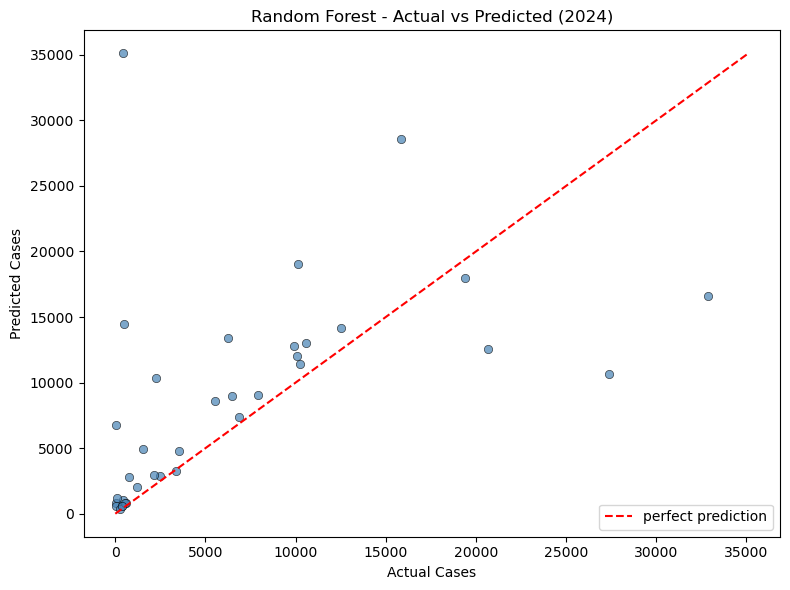

In [30]:
# predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test_rf, y_pred_rf, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.5)
max_val = max(y_test_rf.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='perfect prediction')
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases')
plt.title('Random Forest - Actual vs Predicted (2024)')
plt.legend()
plt.tight_layout()
plt.show()

Feature Importance:
prev_year_cases    0.581209
state_code         0.191340
population         0.127158
year               0.100292
dtype: float64


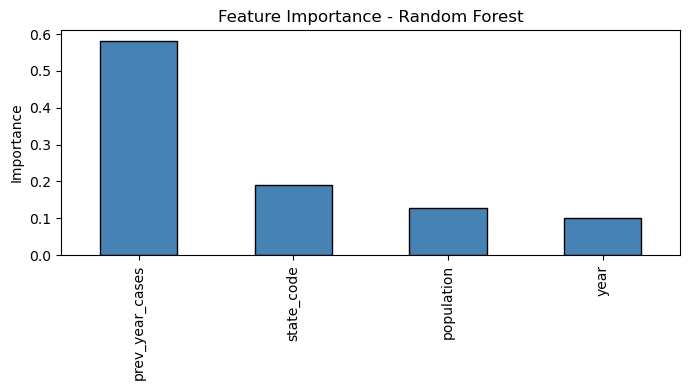

In [31]:
# feature importance
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importance:")
print(feat_imp)

plt.figure(figsize=(7, 4))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [32]:
# comparing predictions for each state
results = test[['state', 'cases']].copy().reset_index(drop=True)
results['predicted'] = y_pred_rf.round(0).astype(int)
results['error'] = results['cases'] - results['predicted']
results = results.sort_values('cases', ascending=False).reset_index(drop=True)
print(results.to_string())

                state    cases  predicted    error
0           Karnataka  32886.0      16571  16315.0
1          Tamil Nadu  27378.0      10651  16727.0
2              Kerala  20674.0      12591   8083.0
3         Maharashtra  19385.0      17976   1409.0
4       Uttar Pradesh  15868.0      28569 -12701.0
5           Rajasthan  12514.0      14181  -1667.0
6               Delhi  10585.0      13033  -2448.0
7      Madhya Pradesh  10224.0      11423  -1199.0
8               Bihar  10157.0      19033  -8876.0
9           Telangana  10077.0      12015  -1938.0
10             Odisha   9892.0      12802  -2910.0
11            Gujarat   7891.0       9084  -1193.0
12              J & K   6876.0       7391   -515.0
13            Haryana   6469.0       9009  -2540.0
14             Punjab   6260.0      13383  -7123.0
15     Andhra Pradesh   5555.0       8563  -3008.0
16        Chattisgarh   3523.0       4766  -1243.0
17   Himachal Pradesh   3359.0       3234    125.0
18            Manipur   2463.0 

## Summary & Conclusions

In [33]:
print("="*55)
print("SUMMARY")
print("="*55)
print()
print("Key observations from EDA:")
print("- Dengue cases in India have been rising steadily since 1991")
print("- 2023 had the highest ever cases: 289,235")
print("- 2020 had a dip - likely due to COVID lockdown reducing outdoor activity")
print("- Karnataka, Tamil Nadu and Kerala had highest cases in 2024")
print("- Mobility (especially transit) shows some correlation with case counts")
print()
print("Model Results:")
print(f"- Linear Regression (national): RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} cases")
print(f"- Random Forest (state panel) : RMSE = {rmse_rf:,.0f} cases")
print()
print("Limitations:")
print("- No climate/rainfall data (big factor for dengue mosquito breeding)")
print("- State model only trained on 3 years of data")
print("- Mobility data only available till 2022")
print("- Under-reporting is likely common especially in rural areas")

SUMMARY

Key observations from EDA:
- Dengue cases in India have been rising steadily since 1991
- 2023 had the highest ever cases: 289,235
- 2020 had a dip - likely due to COVID lockdown reducing outdoor activity
- Karnataka, Tamil Nadu and Kerala had highest cases in 2024
- Mobility (especially transit) shows some correlation with case counts

Model Results:
- Linear Regression (national): RMSE = 120,608 cases
- Random Forest (state panel) : RMSE = 8,288 cases

Limitations:
- No climate/rainfall data (big factor for dengue mosquito breeding)
- State model only trained on 3 years of data
- Mobility data only available till 2022
- Under-reporting is likely common especially in rural areas
